In [1]:
import sys
sys.path.append('../src')

In [2]:
import numpy as np
from data_generator import build_cholesky_factor, sample_functions, compute_antiderivative
import matplotlib.pyplot as plt

In [3]:
n_fine = 100
ell = .5
rng= np.random.default_rng(40)
x_fine = np.linspace(0, 1, n_fine)

In [10]:
L = build_cholesky_factor(x_fine, ell)
u = sample_functions(L, 1, rng)

In [5]:
integral = compute_antiderivative(u = u, x_fine=x_fine)

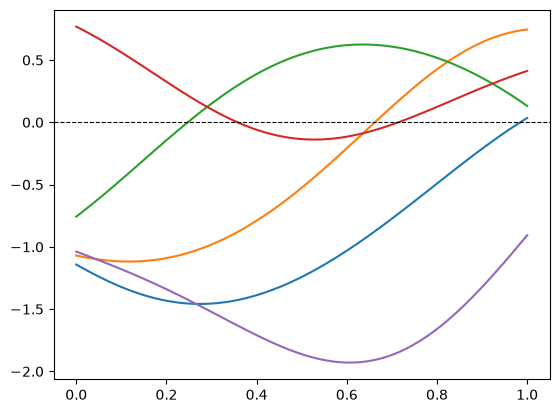

In [6]:
for i in range(u.shape[0]):
    plt.plot(x_fine, u[i])
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

In [13]:
# validation cell (run separately from plotting)
x_fine = np.linspace(0, 1, 100)
ell = 0.2
rng = np.random.default_rng(0)

L = build_cholesky_factor(x_fine, ell)
K = L @ L.T

# 1. Shape and orientation
u = sample_functions(L, 20000, rng)
print("u.shape:", u.shape)          # expect (20000, 100)

C = np.cov(u.T) if u.shape[0] > u.shape[1] else np.cov(u)
print("cov shape:", C.shape)        # expect (100, 100)

# 2. Covariance recovery
print("max |cov - K|:", np.abs(C - K).max())        # expect ~0.01

# 3. Pointwise variance — catches the upper/lower bug
v = u.var(axis=0)
print("var min/max:", v.min(), v.max())             # expect both ~1.0

# 4. Quadrature: exact on constants
s = compute_antiderivative(np.ones((1, 100)), x_fine)
print("constant test:", np.abs(s[0] - x_fine).max())   # expect ~1e-16

# 5. Quadrature: O(h^2) on a known case
f = np.sin(2 * np.pi * x_fine)[None, :]
exact = (1 - np.cos(2 * np.pi * x_fine)) / (2 * np.pi)
print("sine test:", np.abs(compute_antiderivative(f, x_fine)[0] - exact).max())

u.shape: (20000, 100)
cov shape: (100, 100)
max |cov - K|: 0.01681894516379248
var min/max: 0.9907692801949474 1.0142369443350454
constant test: 0.0
sine test: 0.00010682626592101174
